# 🏨 Predicción de Cancelación de Reservas Hoteleras
##  Máster en Data Science & IA · Evolve Academy

**Dataset:** Hotel Booking Demand — Antonio, Almeida & Nunes (2019)  
**Tarea:** Clasificación binaria · `is_canceled` (37% positivos)   
**Objetivo** es Predecir aquellas reservas que tienen una alta probabilidad de ser cancaledas.  


## 0. Entorno y dependencias

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef, roc_curve
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# import xgboost as xgb
# import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# import dalex as dx

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
RANDOM_STATE = 42


## 1. Carga y primera inspección

El dataset es público y está disponible directamente desde el repositorio de TidyTuesday (espejo del paper original).  
También puede descargarse desde Kaggle: `jessemostipak/hotel-booking-demand`.


In [2]:
df_raw = pd.read_csv("data/reservas_hoteleras.csv")

In [3]:
df_raw.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02


### Diccionario de variables
*Fuente: Antonio, Almeida & Nunes (2019). Hotel booking demand datasets. Data in Brief, 22, 41–49.*

| Variable | Tipo | Descripción |
|---|---|---|
| `hotel` | Categórica | Tipo de hotel: H1 = Resort Hotel, H2 = City Hotel |
| `is_canceled` | Binaria (target) | 1 = reserva cancelada, 0 = no cancelada |
| `lead_time` | Numérica | Días entre la fecha de reserva y la fecha de llegada |
| `arrival_date_year` | Numérica | Año de llegada |
| `arrival_date_month` | Categórica | Mes de llegada |
| `arrival_date_week_number` | Numérica | Semana del año de llegada |
| `arrival_date_day_of_month` | Numérica | Día del mes de llegada |
| `stays_in_weekend_nights` | Numérica | Noches de fin de semana (sáb/dom) reservadas o estancia real |
| `stays_in_week_nights` | Numérica | Noches entre semana (lun–vie) reservadas o estancia real |
| `adults` | Numérica | Número de adultos |
| `children` | Numérica | Número de niños |
| `babies` | Numérica | Número de bebés |
| `meal` | Categórica | Régimen alimenticio: SC/Undefined = sin paquete; BB = solo desayuno; HB = media pensión; FB = pensión completa |
| `country` | Categórica | País de origen del cliente (formato ISO 3155-3:2013) |
| `market_segment` | Categórica | Segmento de mercado. TA = Travel Agents, TO = Tour Operators |
| `distribution_channel` | Categórica | Canal de distribución de la reserva. TA = Travel Agents, TO = Tour Operators |
| `is_repeated_guest` | Binaria | 1 = cliente repetidor, 0 = primera vez |
| `previous_cancellations` | Numérica | Número de cancelaciones previas del cliente |
| `previous_bookings_not_canceled` | Numérica | Número de reservas previas no canceladas del cliente |
| `reserved_room_type` | Categórica | Código del tipo de habitación reservada (anonimizado) |
| `assigned_room_type` | Categórica | Código del tipo de habitación asignada (puede diferir de la reservada por overbooking o petición del cliente) |
| `booking_changes` | Numérica | Número de modificaciones realizadas sobre la reserva hasta check-in o cancelación |
| `deposit_type` | Categórica | Depósito realizado: No Deposit = sin depósito; Non Refund = depósito por el total de la estancia; Refundable = depósito parcial reembolsable |
| `agent` | Categórica | ID de la agencia de viajes que realizó la reserva (anonimizado) |
| `company` | Categórica | ID de la empresa responsable de la reserva o del pago (anonimizado) |
| `days_in_waiting_list` | Numérica | Días que la reserva estuvo en lista de espera antes de confirmarse |
| `customer_type` | Categórica | Tipo de reserva: Contract = con contrato; Group = grupo; Transient = individual sin contrato; Transient-party = individual asociado a otra reserva transient |
| `adr` | Numérica | Average Daily Rate: precio medio por noche (€) |
| `required_car_parking_spaces` | Numérica | Plazas de aparcamiento solicitadas por el cliente |
| `total_of_special_requests` | Numérica | Número de peticiones especiales del cliente (ej. cama doble, piso alto) |
| `reservation_status` | Categórica |  — último estado: Canceled / Check-Out / No-Show |
| `reservation_status_date` | Fecha |  — fecha en que se estableció el último estado |

In [4]:
# resumen de variables del dataframe, mostrando el tipo de dato, cantidad de nulos, porcentaje de nulos y cantidad de valores únicos. Solo se muestran las variables que tienen nulos
def resumen_variables(df):
    resumen = pd.DataFrame({
        "dtype": df.dtypes,
        "nulos": df.isnull().sum(),
        "pct_nulos": df.isnull().mean() * 100,
        "n_unique": df.nunique()
    })
    return resumen[resumen["nulos"] > 0]
resumen_variables(df_raw)


,dtype,nulos,pct_nulos,n_unique
children,float64,4,0.0034,5
country,str,488,0.4087,177
agent,float64,16340,13.6862,333
company,float64,112593,94.3069,352


In [5]:
# Distribución del target
print(df_raw["is_canceled"].value_counts())
print(f"\nTasa de cancelación: {df_raw['is_canceled'].mean():.1%}")


is_canceled
0    75166
1    44224
Name: count, dtype: int64

Tasa de cancelación: 37.0%


## 2. EDA Tecnico


In [6]:
df=df_raw.copy()

### ⚠️ Ojo posibles variables con data leakage??? — exclusión obligatoria


El modelo se usará **en el momento de hacer la reserva**. Por tanto, cualquier variable
que se conozca o se modifique después de ese momento es *data leakage*: el modelo
estaría "viendo el futuro" y en producción no funcionaría.

Revisamos las variables sospechosas comparando su tasa de cancelación.

In [7]:
# Función auxiliar: gtasa de cancelación y número de reservas por cada valor de una variable
def tasa_cancelacion(df, col):
    return df.groupby(col)['is_canceled'].agg(reservas='size', tasa_cancelacion='mean')

tasa_cancelacion(df, 'reservation_status')

,reservas,tasa_cancelacion
reservation_status,,
Canceled,43017,1.0000
Check-Out,75166,0.0000
No-Show,1207,1.0000


In [8]:
# ¿Qué pasa cuando la habitación asignada es distinta de la reservada?
df['habitacion_cambiada'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
tasa_cancelacion(df, 'habitacion_cambiada')

,reservas,tasa_cancelacion
habitacion_cambiada,,
0,104473,0.4156
1,14917,0.0538


In [9]:
tasa_cancelacion(df, 'required_car_parking_spaces')

,reservas,tasa_cancelacion
required_car_parking_spaces,,
0,111974,0.3949
1,7383,0.0000
2,28,0.0000
3,3,0.0000
8,2,0.0000


In [10]:
# booking_changes: la agrupo en 0, 1, 2, 3+ para que se lea mejor
tasa_cancelacion(df, df['booking_changes'].clip(upper=3))

,reservas,tasa_cancelacion
booking_changes,,
0,101314,0.4085
1,12701,0.1423
2,3805,0.2013
3,1570,0.1656


**Decisión sobre las variables con fuga de información:**

| Variable | Decisión | Motivo |
|---|---|---|
| `reservation_status` | Excluir | Es el resultado de la reserva (Canceled / Check-Out / No-Show). |
| `reservation_status_date` | Excluir | Fecha de cancelación o de check-out, posterior a la reserva. |
| `assigned_room_type` | Excluir | La habitación se asigna al llegar al hotel. |
| `required_car_parking_spaces` | Excluir | 0% de cancelación con parking: se registra en el check-in. |
| `booking_changes` | Excluir | Cuenta los cambios hasta la llegada. Al reservar vale siempre 0. |
| `days_in_waiting_list` | Excluir | Se conoce al confirmar la reserva, no al solicitarla. Por prudencia, fuera. |

In [11]:
VARIABLES_FUGA = ['reservation_status', 'reservation_status_date', 'assigned_room_type', 'required_car_parking_spaces', 'booking_changes', 'days_in_waiting_list']

df = df.drop(columns=VARIABLES_FUGA + ['habitacion_cambiada']) # quito también la variable temporal
print(f"Columnas restantes: {df.shape[1]}")

Columnas restantes: 26


---
## 2. EDA — Análisis exploratorio con foco de negocio

Cada gráfico debe responder a una pregunta de negocio concreta.


In [12]:
# Colores fijos para todo el notebook: azul = no cancela, naranja = cancela
C_NO, C_SI, C_GRIS = '#2a78d6', '#eb6834', '#8a8983'
TASA_GLOBAL = df['is_canceled'].mean()

def barras_tasas(tabla, titulo, ax, rotar=0):
    """
    Dibuja la tasa de cancelación en función de la categoría, utilizando como
    referencia la media global
    """
    ax.bar(tabla.index.astype(str), tabla['tasa_cancelacion'], color=C_SI, width=0.6)
    ax.axhline(TASA_GLOBAL, color=C_GRIS, ls='--', lw=1)    #Línea de la media
    ax.text(len(tabla) - 0.5, TASA_GLOBAL + 0.015, f'media {TASA_GLOBAL:.0%}', color=C_GRIS, ha='right', fontsize=9)
    for i, v in enumerate(tabla['tasa_cancelacion']):
        ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=rotar)

### 2.1 Cancelación por hotel

**Pregunta de negocio:** ¿los dos hoteles tienen el mismo problema de cancelacion?

              reservas  tasa_cancelacion
hotel                                   
City Hotel       79330            0.4173
Resort Hotel     40060            0.2776


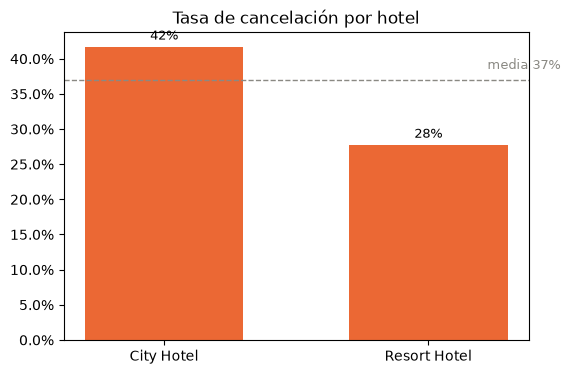

In [13]:
t_hotel =tasa_cancelacion(df, 'hotel')
print(t_hotel)

fig, ax = plt.subplots(figsize=(6, 4))
barras_tasas(t_hotel, 'Tasa de cancelación por hotel', ax)
plt.show()

El **City Hotel cancela un 42%** frente al **28% del Resort**, un 14% más y, además, concentra dos tercios de las reservas.

>💡 **Conclusión accionable:** el City Hotel debe ser la prioridad. Ahí se concentra el volumen de cancelaciones, por lo que está justificada una política de overbooking más agresiva. El Resort, con clientes vacacionales que planifican más, necesita menos intervención.

### 2.2 Cancelación por mes de llegada

**Pregunta de negocio:** ¿hay épocas del año con más cancelaciones? ¿Coinciden con la temporada alta?

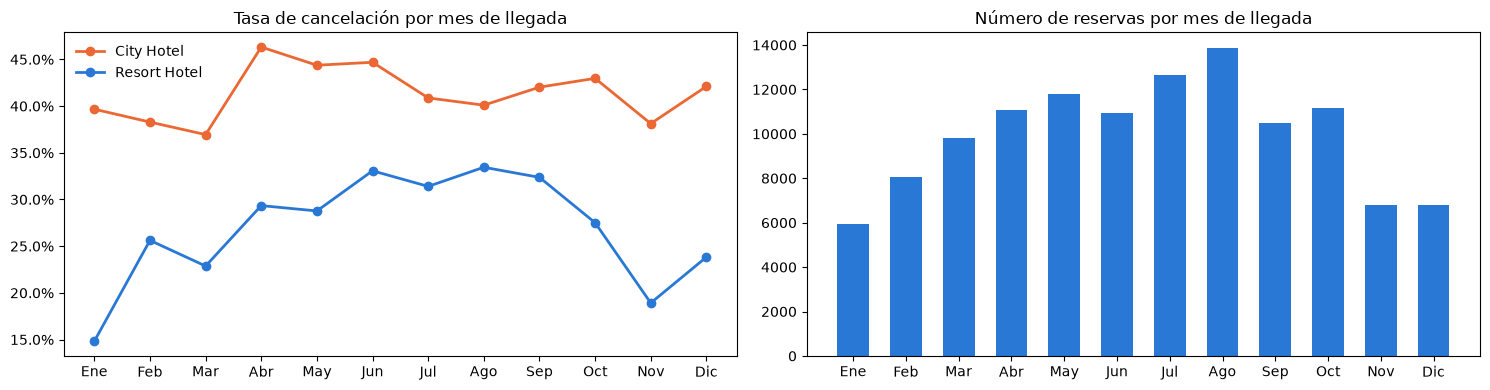

In [14]:
# Orden natural de los meses
MESES = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
MESES_ES = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Tasa de cancelación por mes y hotel
t_mes = df.groupby(['arrival_date_month', 'hotel'])['is_canceled'].mean().unstack().loc[MESES]

# Número de reservas por mes
vol_mes = df['arrival_date_month'].value_counts().loc[MESES]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Gráfico 1: Tasa de cancelación
axes[0].plot(MESES_ES, t_mes['City Hotel'], marker='o', lw=2, color=C_SI, label='City Hotel')
axes[0].plot(MESES_ES, t_mes['Resort Hotel'], marker='o', lw=2, color=C_NO, label='Resort Hotel')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Tasa de cancelación por mes de llegada')
axes[0].legend(frameon=False)

# Gráfico 2: Volumen de reservas
axes[1].bar(MESES_ES, vol_mes.values, color=C_NO, width= 0.6)
axes[1].set_title('Número de reservas por mes de llegada')

plt.tight_layout()
plt.show()

- En el **City Hotel** la cancelación es alta todo el año (37-46%), con picos en **Abril-Junio**.
- En el **Resort Hotel** sube en **verano (Junio-Septiembre)** mánteniéndose entre un **31-33%**, justo cuando hay más reservas, y baja mucho en invierno (**15% en Enero**).
- La temporada alta concentra, a la vez, **más reservas y más cancelaciones**.

> 💡 **Conclusión accionable:** las acciones preventivas (depósito, overbooking) deben **intensificarse en temporada alta**, cuando una habitación vacía cuesta más porque habría otros cliente que la habrían ocupado.

### 2.3 Cancelación por canal de distribución y segmento de mercado

**Pregunta de negocio:** ¿influye el canal por el que llega la reserva en la probabilidad de cancelar?

                reservas  tasa_cancelacion  % reservas
market_segment                                        
Groups             19811            0.6106     16.6000
Online TA          56477            0.3672     47.3000
Offline TA/TO      24219            0.3432     20.3000
Aviation             237            0.2194      0.2000
Corporate           5295            0.1873      4.4000
Direct             12606            0.1534     10.6000
Complementary        743            0.1306      0.6000


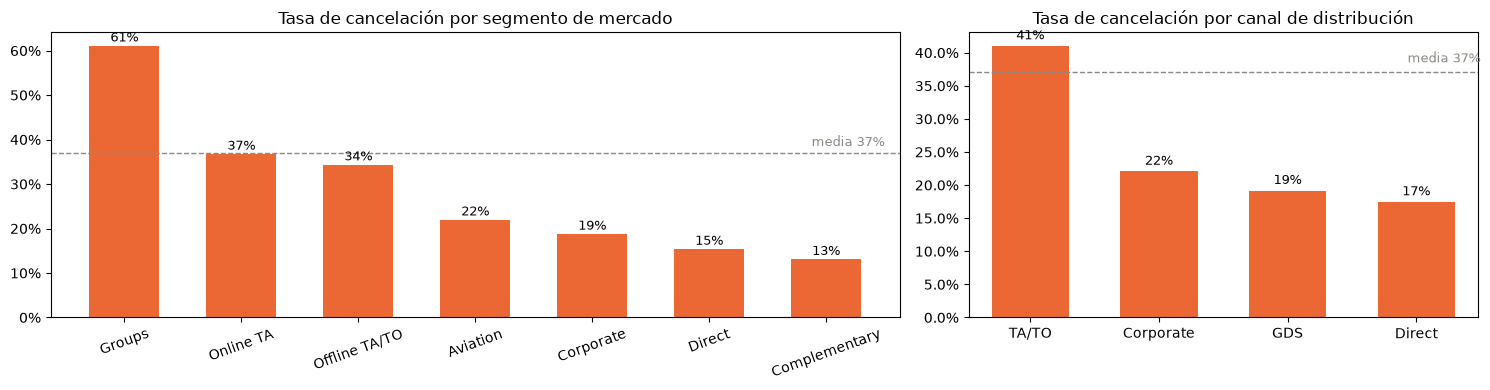

In [15]:
# Quito la categoría 'Undefined'
t_seg = tasa_cancelacion(df[df['market_segment'] != 'Undefined'], 'market_segment').sort_values('tasa_cancelacion', ascending=False)
t_canal = tasa_cancelacion(df[df['distribution_channel'] != 'Undefined'], 'distribution_channel').sort_values('tasa_cancelacion', ascending=False)

t_seg['% reservas'] = (t_seg['reservas'] / t_seg['reservas'].sum() * 100).round(1)  # peso de cada segmento
print(t_seg)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={'width_ratios': [2, 1.2]})
barras_tasas(t_seg, 'Tasa de cancelación por segmento de mercado', axes[0], rotar=20)
barras_tasas(t_canal, 'Tasa de cancelación por canal de distribución', axes[1])
plt.tight_layout()
plt.show()

- **Groups (61%)** y **Online TA (37%)** son los segmentos que más cancelan. Online TA es, además, el segmento más grande (47% de las reservas), así que es el que más cancelaciones aporta.
- **Corporate (19%)** y **Direct (15%)** son los más fiables: el cliente viaja por trabajo o tiene relación directa con el hotel.
- Por canal, **TA/TO (41%)** duplica el canal **Direct (17%)**.

> 💡 **Conclusión accionable:** conviene **impulsar la venta directa** (web propia, programa de fidelización), porque, además de ahorrar la comisión de la agencia, reduce la cancelación a menos de la mitad. Para los **grupos**, los contratos deberían incluir fechas de liberación de habitaciones escalonadas y penalizaciones.

### 2.4 Relación entre lead time y cancelación

**Pregunta de negocio:** ¿las reservas hechas con mucha antelación se cancelan más?

            reservas  tasa_cancelacion
lead_tramo                            
0-7 d          19746            0.0963
8-30 d         18960            0.2786
31-90 d        29553            0.3770
91-180 d       26439            0.4471
181-365 d      21544            0.5545
>1 año          3148            0.6766


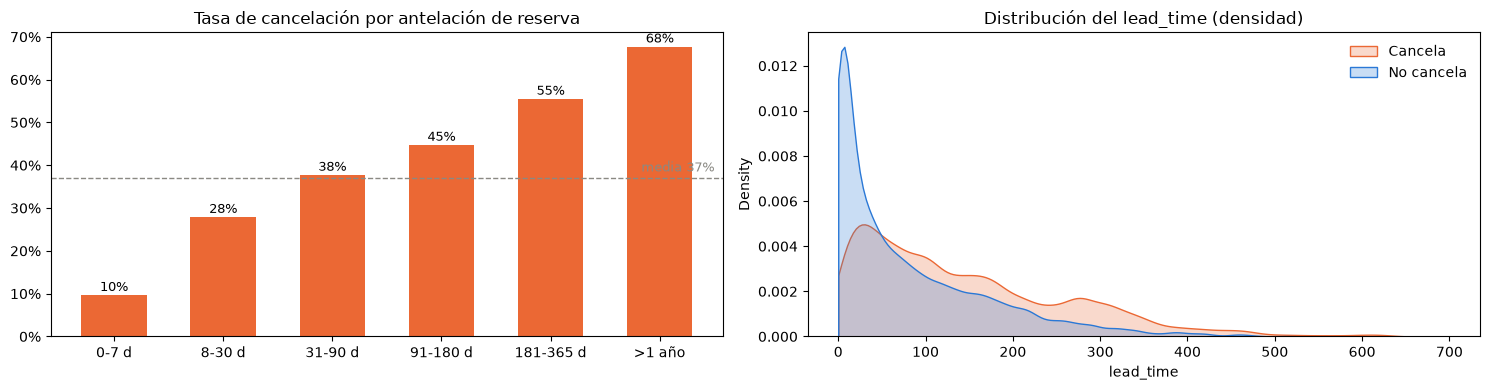

In [16]:
# Agrupo el lead time en tramos con sentido de negocio
tramos = [-1, 7, 30, 90, 180, 365, 800]
etiquetas = ['0-7 d', '8-30 d', '31-90 d', '91-180 d', '181-365 d', '>1 año']
df['lead_tramo'] = pd.cut(df['lead_time'], bins=tramos, labels=etiquetas)

t_lead = tasa_cancelacion(df, 'lead_tramo')
print(t_lead)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Gráfico 1: Tasa de cancelación por tramo
barras_tasas(t_lead, 'Tasa de cancelación por antelación de reserva', axes[0])

# Gráfico 2: Distribución del lead_time en canceladas y no canceladas
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', common_norm=False, fill=True, alpha=0.25, palette={0: C_NO, 1: C_SI}, clip=(0, 700), ax=axes[1])
axes[1].set_title('Distribución del lead_time (densidad)')
axes[1].legend(['Cancela', 'No cancela'], frameon=False)

plt.tight_layout()
plt.show()

Relación **creciente y muy marcada**: las reservas de última hora (≤ 7 días) cancelan solo un **10%**, mientras que las hechas con más de 6 meses de antelación, cancelan un **55%**, y las de más de un año un **68%**. Cuanto más tiempo pasa entra la reserva y la llegada, más oportunidades tiene el cliente de cambiar de planes o de encontrar una oferta mejor.

>💡**Conclusión accionable:** para reservas con **más de 90 días de antelación** conviene pedir un **depósito parcial** o enviar **confirmaciones intermedias** (a 60 y 30 días de la llegada), para detectar a tiempo las habitaciones que se van a liberar y poder revenderlas.

### 2.5 ADR medio en reservas canceladas y no canceladas

**Pregunta de negocio:** ¿las reservas que se cancelan son más caras o más baratas?

count   119390.0000
mean       101.8000
std         50.5000
min         -6.4000
1%           0.0000
50%         94.6000
99%        252.0000
max       5400.0000
Name: adr, dtype: float64

Reservas con ADR = 0:   1,959
Reservas con ADR < 0:   1
Reservas con ADR > 1000: 1


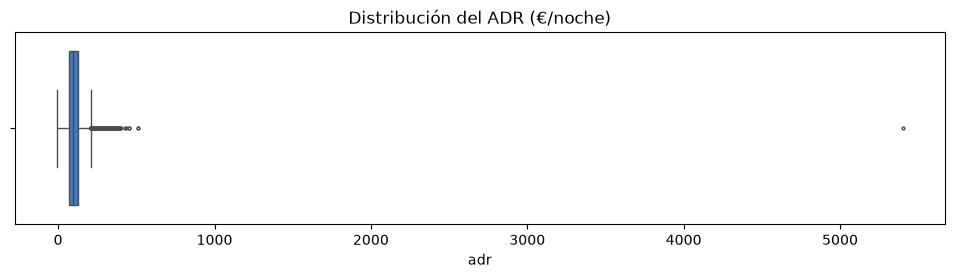

In [17]:
# Antes de analizar el ADR, reviso sus valores extremos
print(df['adr'].describe(percentiles=[0.01, 0.5, 0.99]).round(1))
print(f"\nReservas con ADR = 0:   {(df['adr'] == 0).sum():,}")
print(f"Reservas con ADR < 0:   {(df['adr'] < 0).sum():,}")
print(f"Reservas con ADR > 1000: {(df['adr'] > 1000).sum():,}")

fig, ax = plt.subplots(figsize=(12, 2.5))
sns.boxplot(x=df['adr'], color=C_NO, fliersize=2, ax=ax)
ax.set_title('Distribución del ADR (€/noche)')
plt.show()

- El ADR tiene un valor de **5.400 €/noche**, más de 20 veces el percentil 99 (252 €), y uno
  **negativo**. Son errores de registro: los excluyo del análisis y los trataré en la limpieza.
- Las reservas con **ADR = 0** son estancias de cortesía o incluidas en paquetes. Son reales,
  pero las dejaré fuera de la comparación de precios porque bajarían artificialmente las medias.

                             mean   median
hotel        is_canceled                  
City Hotel   0           108.3000 100.2000
             1           104.9000 100.0000
Resort Hotel 0            92.9000  74.0000
             1           106.6000  84.0000


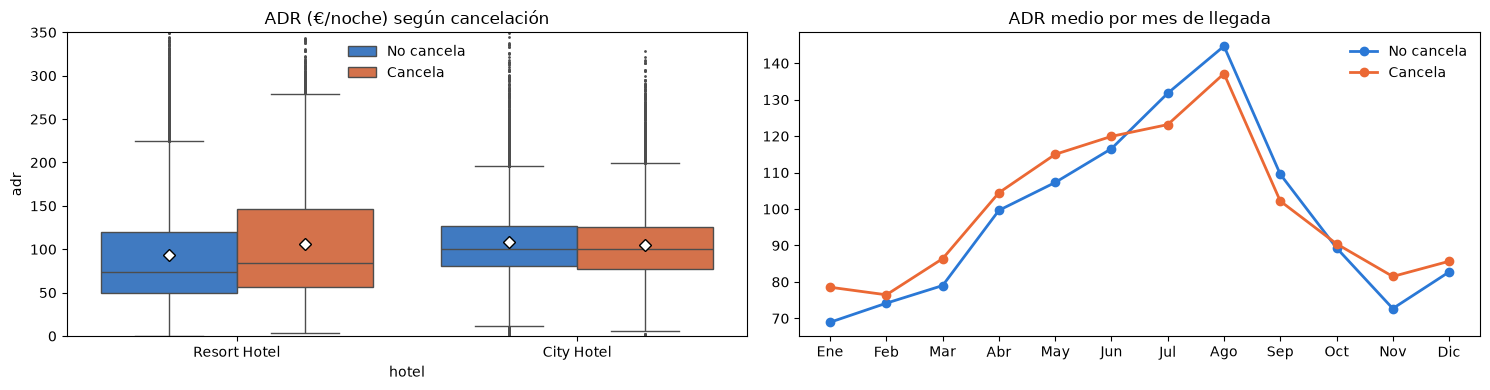

In [18]:
# Excluyo ADR <= 0 (estancias gratuitas) y el valor anómalo de 5.400€, que distorsionaría las medias
adr_ok = df[(df['adr'] > 0) & (df['adr'] < 1000)]

# Media y mediana del ADR por hotel y cancelación
resumen_adr = adr_ok.groupby(['hotel', 'is_canceled'])['adr'].agg(['mean', 'median']).round(1)
print(resumen_adr)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Gráfico 1: boxplot del ADR por hotel y cancelación
sns.boxplot(data=adr_ok, x='hotel', y='adr', hue='is_canceled', palette={0: C_NO, 1: C_SI}, fliersize=1, ax=axes[0], showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 6})
axes[0].set_ylim(0, 350)
axes[0].set_title('ADR (€/noche) según cancelación')
handles, _ =axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['No cancela', 'Cancela'], frameon=False)

# Gráfico 2: ADR medio por mes, para ver si la diferencia viene de la estacionalidad
adr_mes = adr_ok.groupby(['arrival_date_month', 'is_canceled'])['adr'].mean().unstack().loc[MESES]
axes[1].plot(MESES_ES, adr_mes[0], marker='o', lw=2, color=C_NO, label='No cancela')
axes[1].plot(MESES_ES, adr_mes[1], marker='o', lw=2, color=C_SI, label='Cancela')
axes[1].set_title('ADR medio por mes de llegada')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

- En global, las reservas canceladas tienen un **ADR medio ligeramente mayor**
  (105 € frente a 102 €).
- El efecto **depende del hotel** (ver tabla y rombos del boxplot):
  - En el **Resort**, las canceladas son claramente más caras: **media de 107 € frente a 93 €**
    y mediana de 84 € frente a 74 €.
  - En el **City Hotel** apenas hay diferencia: la mediana es la misma (~100 €) y la media es
    incluso algo menor en las canceladas (105 € frente a 108 €).
- En el gráfico por meses se ve que el ADR se dispara en verano, que es cuando más se cancela.
  Mes a mes, las dos curvas van mucho más juntas, así que buena parte de la diferencia se debe
  a la **estacionalidad** y no al precio en sí.
- Por tanto, el ADR **por sí solo no es un buen predictor**, pero en el Resort **las cancelaciones
  se llevan las habitaciones más caras** (las de temporada alta).

> 💡 **Conclusión accionable:** en el Resort, cada cancelación no detectada en verano cuesta más
> que el ADR medio. Para priorizar acciones conviene ordenar las reservas de riesgo por
> **ingreso en riesgo** (probabilidad de cancelación × ADR × noches), no solo por probabilidad.

### 2.6 Otras variables relevantes

**Pregunta de negocio:** ¿qué características del cliente y de la reserva indican más o menos compromiso con el viaje?

--- Tipo de depósito ---
              reservas  tasa_cancelacion
deposit_type                            
No Deposit      104641            0.2840
Non Refund       14587            0.9940
Refundable         162            0.2220 

--- Peticiones especiales ---
            reservas  tasa_cancelacion
peticiones                            
0              70318            0.4770
1              33226            0.2200
2              12969            0.2210
3+              2877            0.1680 

--- Cancelaciones previas ---
                       reservas  tasa_cancelacion
cancelaciones_previas                            
0                        112906            0.3390
1                          6051            0.9440
2+                          433            0.5270 

--- Cliente repetidor ---
           reservas  tasa_cancelacion
cliente                              
Nuevo        115580            0.3780
Repetidor      3810            0.1450 

--- País (8 más frecuentes) ---
        

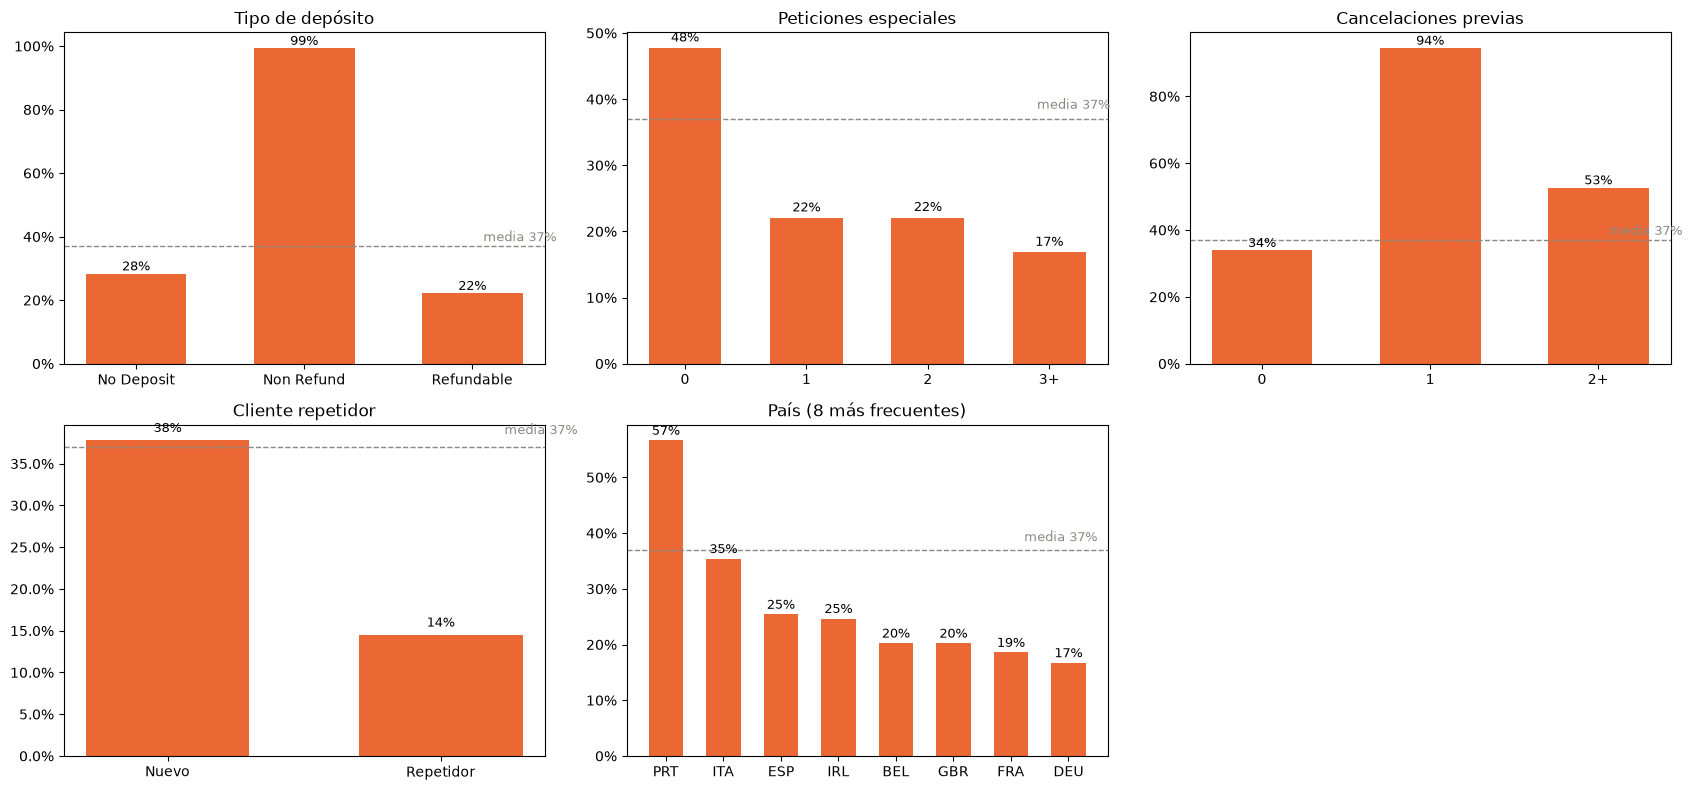

In [19]:
# Variables auxiliares agrupadas (en texto para que el orden y las etiquetas salgan bien)
peticiones = df['total_of_special_requests'].clip(upper=3).astype(str).replace({'3': '3+'})
cancel_prev =df['previous_cancellations'].clip(upper=2).astype(str).replace({'2': '2+'})
repetidor = df['is_repeated_guest'].map({0: 'Nuevo', 1: 'Repetidor'})
top_paises = df['country'].value_counts().head(8).index

tablas = {
    'Tipo de depósito': tasa_cancelacion(df, 'deposit_type'),
    'Peticiones especiales': tasa_cancelacion(df, peticiones.rename('peticiones')),
    'Cancelaciones previas': tasa_cancelacion(df, cancel_prev.rename('cancelaciones_previas')),
    'Cliente repetidor': tasa_cancelacion(df, repetidor.rename('cliente')),
    'País (8 más frecuentes)': tasa_cancelacion(df[df['country'].isin(top_paises)], 'country').sort_values('tasa_cancelacion', ascending=False),
}

# Imprimo las tablas para tener las cifras exactas
for nombre, t in tablas.items():
    print(f'--- {nombre} ---')
    print(t.round(3), '\n')

# Las dibujo en una cuadrícula de 2 x 3
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (nombre, t) in zip(axes.flat, tablas.items()):
    barras_tasas(t, nombre, ax)
axes.flat[-1].axis('off')   # El sexto hueco de la tabla queda vacío
plt.tight_layout()
plt.show()

El resultado más llamativo es el del **tipo de depósito**: las reservas con depósito
**no reembolsable cancelan el 99%**, justo lo contrario de lo que cabría esperar, porque
quien paga por adelantado sin posibilidad de devolución debería tener más motivos para viajar.

Un resultado tan extremo hay que **investigarlo antes de creérselo**. Reviso quién hace
estas reservas: segmento de mercado, país y antelación.

In [20]:
# Compruebo el perfil de quien hace las reservas con depósito no reembolsable
nr = df[df['deposit_type'] == 'Non Refund']
print(f'Reservas Non Refund: {len(nr):,}')
print('\nSegmento de mercado:')
print(nr['market_segment'].value_counts(normalize=True).head(3).round(2))
print('\nPaís:')
print(nr['country'].value_counts(normalize=True).head(2).round(2))
print(f'\nMediana del lead time: {nr['lead_time'].median():.0f} días (frente a {df['lead_time'].median():.0f} en el total)')

Reservas Non Refund: 14,587

Segmento de mercado:
market_segment
Groups          0.6300
Offline TA/TO   0.3400
Corporate       0.0200
Name: proportion, dtype: float64

País:
country
PRT   0.9700
GBR   0.0100
Name: proportion, dtype: float64

Mediana del lead time: 183 días (frente a 69 en el total)


- **Depósito no reembolsable → 99% de cancelación.** Es contraintuitivo: sería de esperar que el
  depósito retuviera al cliente. Pero estas reservas son casi todas de **grupos y turoperadores**
  (97% de Portugal, con una mediana de antelación de 183 días frente a 69 en el total). Todo apunta a
  **bloques de habitaciones que el intermediario reserva y luego libera**, no a clientes individuales
  que pierden su dinero.
- **Peticiones especiales:** sin ninguna petición cancela el **48%**; con una o más, el **22%** o menos.
  Quien pide una cuna o un piso alto **ya está planificando su estancia**.
- **Cancelaciones previas:** si el cliente ya canceló una vez, la tasa se dispara al **94%**,
  frente al **34%** de quien nunca ha cancelado.
- **Clientes repetidores:** cancelan mucho menos (**14%**) que los nuevos (**38%**).
- **País:** **Portugal (57%)** cancela muchísimo más que los mercados internacionales (17-35%).

---
## 2.7 Tratamiento de nulos


In [21]:
# Repaso que variables tienen nulos ahora (después de quitar las de fuga)
print(resumen_variables(df))

# ¿Cómo se reparten las reservas entre las agencias?
print(f"\nAgencias distintas: {df_raw['agent'].nunique()}")
print(f"Agencias con menos de 100 reservas: {(df_raw['agent'].value_counts() < 100).sum()}")

            dtype   nulos  pct_nulos  n_unique
children  float64       4     0.0034         5
country       str     488     0.4087       177
agent     float64   16340    13.6862       333
company   float64  112593    94.3069       352

Agencias distintas: 333
Agencias con menos de 100 reservas: 249


**La decisión sobre los nulos no es técnica, es de negocio: hay que preguntarse qué significa
que falte ese dato.**

| Variable | Nulos | Qué significa | Decisión |
|---|---|---|---|
| `children` | 4 (0,003%) | Error de registro puntual | Imputar con **0**, el valor más frecuente. Son 4 filas, cualquier opción da igual. |
| `country` | 488 (0,4%) | No se registró la nacionalidad | Imputar con la categoría **'Desconocido'**. No invento un país. |
| `agent` | 16.340 (13,7%) | **No hubo agencia**: la reserva fue directa | No es un dato que falte. Lo convierto en un indicador: `has_agent` (1 = hay agencia, 0 = no). |
| `company` | 112.593 (94,3%) | **No hubo empresa**: no es un viaje corporativo | Igual que el anterior: `has_company`. Con un 94% de nulos, el ID en sí no sirve. |

**Sobre `agent` y `company`:** son **identificadores anonimizados** (el agente 240, el 15...). Su valor
numérico no significa nada: el agente 300 no es "más" que el 150. Además tienen 333 y 352 valores
distintos, así que convertirlos en columnas *dummy* crearía cientos de columnas con muy pocas reservas
cada una. Lo que sí tiene valor de negocio es **si la reserva viene por agencia o por empresa**, y eso
es lo que capturo con los dos indicadores.

In [22]:
# 1) Imputaciones
df['children'] = df['children'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Desconocido')

# 2) "agent" y "company": de ID a indicador (1 = existe, 0= no)
df['has_agent'] = df['agent'].notna().astype(int)
df['has_company'] = df['company'].notna().astype(int)
df = df.drop(columns=['agent', 'company'])  # quito las columnas originales

# 3) Compruebo que no quedan nulos
print('Nulos restantes:', df.isna().sum().sum())

# 4) ¿Aportan señal los nuevos indicadores?
print()
print(tasa_cancelacion(df, 'has_agent').round(3))
print()
print(tasa_cancelacion(df, 'has_company').round(3))

Nulos restantes: 0

           reservas  tasa_cancelacion
has_agent                            
0             16340            0.2470
1            103050            0.3900

             reservas  tasa_cancelacion
has_company                            
0              112593            0.3820
1                6797            0.1750


Ya no quedan nulos. Los dos indicadores nuevos aportan señal: las reservas gestionadas por una
**agencia** cancelan más (39% frente a 25%) y las de **empresa** cancelan mucho menos
(18% frente a 38%), en línea con lo visto en el análisis por segmento de mercado.

## 2.8 Limpieza de valores anómalos

En el EDA detecto varios valores imposibles o sin sentido de negocio. Los trato ahora.

In [23]:
filas_antes = len(df)

# 1) Errores de registro en el ADR: negatico o absurdamente alto (5400€/noche)
df = df[(df['adr'] >= 0) & (df['adr'] <= 1000)]

# 2) Reservas sin ningún huésped
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

# 3) Categorías "Undefined" en segmento y canal (muy pocas filas y sin significado)
df = df[(df['market_segment'] != 'Undefined') & (df['distribution_channel'] != 'Undefined')]

# 4) "Undefined" en meal significa "sin régimen", igual que "SC"
df['meal'] = df['meal'].replace('Undefined', 'SC')

# 5) Quito la variable auxiliar que creé solo para el EDA
df = df.drop(columns=['lead_tramo'])

print(f'Filas eliminadas: {filas_antes - len(df):,} ({(filas_antes - len(df)) / filas_antes:.2%})')
print(f'Filas finales: {len(df):,}')
print(f'Tasa de cancelación tras la limpieza: {df["is_canceled"].mean():.1%}')

Filas eliminadas: 187 (0.16%)
Filas finales: 119,203
Tasa de cancelación tras la limpieza: 37.1%


**Decisiones de limpieza:**

| Caso | Decisión | Motivo |
|---|---|---|
| ADR negativo o > 1.000 € | Eliminar la fila (2 filas) | Precios imposibles: error de registro. |
| ADR = 0 | **Mantener** (~1.960 filas) | Son estancias de cortesía o incluidas en paquete. Son reales. |
| Reservas sin huéspedes | Eliminar (180 filas) | Una reserva sin personas no tiene sentido de negocio. |
| Reservas de 0 noches | **Mantener** (~715 filas) | Son estancias de día (*day use*), habituales en el City Hotel. |
| `market_segment` / `distribution_channel` = 'Undefined' | Eliminar (5 filas) | Categoría sin significado y con muy pocos casos. |
| `meal` = 'Undefined' | Recodificar como 'SC' | Según el diccionario del dataset, significan lo mismo: sin régimen. |
| `lead_time` muy alto (hasta 737 días) | **Mantener** | Son valores plausibles: grupos que reservan con dos años de antelación. |

Solo eliminé el **0,16%** de las filas y la tasa de cancelación apenas cambia (37,1% frente a 37,0%),
así que la limpieza **no introduce sesgo** en la variable objetivo.

---
## 3. Feature Engineering

Construyo variables nuevas a partir de las existentes. **Regla:** si no puedo explicar por qué
una variable debería predecir la cancelación, no la incluyo.

Todas las calculo con información **disponible en el momento de la reserva**, igual que el resto.

| Variable nueva | Cálculo | Justificación de negocio |
|---|---|---|
| `total_guests` | adults + children + babies | El tamaño del grupo condiciona la logística del viaje: cuantas más personas, más difícil es coordinar a todos y más probable es un cambio de planes. |
| `total_nights` | noches entre semana + fin de semana | Distingue escapadas cortas de vacaciones largas, que se planifican de forma distinta. |
| `has_kids` | children + babies > 0 | Las familias con niños dependen del calendario escolar y suelen planificar con más antelación y menos margen de cambio. |
| `adr_per_person` | adr / total_guests | El precio por persona refleja mejor el nivel de gasto del cliente que el precio por habitación: 120 €/noche no es lo mismo para una pareja que para cuatro personas. |
| `ingreso_reserva` | adr × total_nights | Es el **ingreso que el hotel pierde** si la reserva se cancela. Me servirá para priorizar acciones por dinero en riesgo, no solo por probabilidad. |
| `lead_time_log` | log(1 + lead_time) | Comprime la cola larga del lead time. En el EDA vi que el riesgo sube mucho en los primeros meses y luego se aplana: el logaritmo recoge mejor esa forma, sobre todo para la Regresión Logística. |
| `is_domestic` | country == 'PRT' | El cliente nacional no tiene coste de vuelo ni de desplazamiento largo, así que le sale más barato reservar "por si acaso" y cancelar. En el EDA cancela más del doble que el internacional. |
| `has_prev_cancel` | previous_cancellations > 0 | Resume el historial en una señal simple: este cliente ya ha cancelado antes. |
| `has_prev_stays` | previous_bookings_not_canceled > 0 | Cliente con estancias previas completadas, es decir, fiel. |
| `has_special_requests` | total_of_special_requests > 0 | En el EDA vi que lo decisivo es **si pide algo o no**, más que cuántas cosas pida. |
| `arrival_weekday` | día de la semana de la llegada | Distingue escapadas de fin de semana de viajes de trabajo entre semana. |

Las variables `has_agent` y `has_company` ya las creé en la sección 2.7 al tratar los nulos.

In [24]:
# Fecha de llegada: la necesitaré para la partición temporal de la sección 4
df['arrival_month_num'] = df['arrival_date_month'].map({m: i + 1 for i, m in enumerate(MESES)})
df['arrival_date'] = pd.to_datetime(dict(year= df['arrival_date_year'],
                                         month= df['arrival_month_num'],
                                         day= df['arrival_date_day_of_month']))

# --- Variables nuevas ---
# Composición y duración
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['has_kids'] = ((df['children'] + df['babies']) > 0).astype(int)

# Económicas
df['adr_per_person'] = df['adr'] / df['total_guests']   # sin división por cero: ya quité las reservas sin huespedes
df['ingreso_reserva'] = df['adr'] * df['total_nights']  # dinero en riesgo si cancela

# Transformación del lead_time
df['lead_time_log'] = np.log1p(df['lead_time']) # log(1+x): admite lead_time = 0

# Cliente
df['is_domestic'] = (df['country'] == 'PRT').astype(int)
df['has_prev_cancel'] = (df['previous_cancellations'] > 0).astype(int)
df['has_prev_stays'] = (df['previous_bookings_not_canceled'] > 0).astype(int)
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)

# Calendario
df['arrival_weekday'] = df['arrival_date'].dt.dayofweek     # 0 = Lunes, 6 = Domingo

print(f'Columnas totales: {df.shape[1]}')
df[['total_guests', 'total_nights', 'adr_per_person', 'ingreso_reserva', 'lead_time_log']].describe().round(1)

Columnas totales: 39


,total_guests,total_nights,adr_per_person,ingreso_reserva,lead_time_log
count,119203.0000,119203.0000,119203.0000,119203.0000,119203.0000
mean,2.0000,3.4000,55.0000,358.3000,3.8000
std,0.7000,2.5000,28.0000,335.6000,1.6000
min,1.0000,0.0000,0.0000,0.0000,0.0000
25%,2.0000,2.0000,37.4000,146.7000,2.9000
50%,2.0000,3.0000,49.5000,267.0000,4.2000
75%,2.0000,4.0000,66.0000,446.6000,5.1000
max,55.0000,69.0000,510.0000,7590.0000,6.6000


In [25]:
# Compruebo si las nuevas variables binarias aportan señal
binarias = ['has_kids', 'is_domestic', 'has_prev_cancel', 'has_prev_stays', 'has_special_requests', 'has_agent', 'has_company']

comprobacion = pd.DataFrame({
    'tasa si = 0': [df[df[v] == 0]['is_canceled'].mean() for v in binarias],
    'tasa si = 1': [df[df[v] == 1]['is_canceled'].mean() for v in binarias],
}, index=binarias)
comprobacion['diferencia'] = (comprobacion['tasa si = 1'] - comprobacion['tasa si = 0']).abs()
comprobacion.sort_values('diferencia', ascending=False).round(3)

,tasa si = 0,tasa si = 1,diferencia
has_prev_cancel,0.3390,0.9170,0.5770
is_domestic,0.2360,0.5670,0.3310
has_prev_stays,0.3810,0.0550,0.3250
has_special_requests,0.4780,0.2180,0.2600
has_company,0.3830,0.1740,0.2080
has_agent,0.2470,0.3900,0.1440
has_kids,0.3730,0.3490,0.0230


**Comprobación de las variables nuevas:** casi todas separan bien las dos clases.

- `has_prev_stays`: 38% frente a **5,5%**. Un cliente con estancias previas completadas casi no cancela.
- `has_prev_cancel`: 34% frente a **92%**. La señal más fuerte del historial.
- `is_domestic`: 24% frente a **57%**.
- `has_special_requests`: 48% frente a **22%**.
- `has_company`: 38% frente a **18%**; `has_agent`: 25% frente a **39%**.

**La excepción es `has_kids`:** 37,3% frente a 34,9%, apenas 2 puntos de diferencia. **No aporta
casi nada.** La mantengo como candidata, porque puede resultar útil combinada con otras variables
(por ejemplo, familias con niños y mucha antelación), y comprobaré su aportación real en la sección
de interpretabilidad. Si no aporta, el modelo simplemente no la usará.

> **Nota metodológica:** esta comprobación es **exploratoria**, no una selección de variables. Estoy
> mirando el dataset completo, incluido el futuro. La decisión final sobre qué variables aportan la
> tomo con el modelo y con datos de validación, no aquí.

**Una variable pendiente: `country`.**

Tiene más de 170 países distintos y muchos con muy pocas reservas. La voy a agrupar, dejando los
más frecuentes y metiendo el resto en una categoría 'Otros'.

Pero esa agrupación **no la puedo hacer todavía**: los países más frecuentes tengo que calcularlos
**solo con los datos de entrenamiento**. Si usara el dataset completo, estaría metiendo información
del periodo de test en el modelo, que es una forma sutil de fuga de información.

Por eso creo `country_grp` en la **sección 4**, después de partir en train y test.

---
## 4. Train y Test




Las reservas de este dataset abarcan dos años, y el comportamiento de los clientes cambia con el
tiempo. Por eso la partición no puede ser aleatoria.

Si repartiera las filas al azar, entrenaría con reservas de 2017 y evaluaría con reservas de 2015:
el modelo estaría "viendo el futuro" y su resultado sería engañosamente bueno. En producción, el
hotel entrena con el histórico y predice reservas **futuras**, así que la evaluación tiene que
reproducir esa situación.

Parto por **fecha de llegada**:

- **Train:** julio 2015 → diciembre 2016 (18 meses, con una temporada completa de cada estación).
- **Test:** enero → agosto 2017 (8 meses que el modelo no ha visto nunca, de temporada baja y alta).

In [26]:
FECHA_CORTE = '2017-01-01'

# Ordeno cronológicamente
df = df.sort_values('arrival_date').reset_index(drop=True)

train = df[df['arrival_date'] < FECHA_CORTE].copy()
test = df[df['arrival_date'] >= FECHA_CORTE].copy()

resumen_split = pd.DataFrame({
    'desde': [train['arrival_date'].min().date(), test['arrival_date'].min().date()],
    'hasta': [train['arrival_date'].max().date(), test['arrival_date'].max().date()],
    'reservas': [len(train), len(test)],
    '% del total': [len(train) / len(df), len(test) / len(df)],
    'tasa cancelación': [train['is_canceled'].mean(), test['is_canceled'].mean()]
}, index=['train', 'test'])

resumen_split.round(3)

,desde,hasta,reservas,% del total,tasa cancelación
train,2015-07-01,2016-12-31,78584,0.6590,0.3620
test,2017-01-01,2017-08-31,40619,0.3410,0.3870


El train se queda con **78.584 reservas (66%)** y el test con **40.619 (34%)**. Las tasas de
cancelación son parecidas (36% frente a 38%), así que el test es representativo: no me ha tocado
un periodo anómalo que haga que las métricas finales no sean creíbles.

### Agrupación de países

`country` tiene más de 170 categorías, y la mayoría con muy pocas reservas. Si la dejara tal cual,
el `OneHotEncoder` crearía 170 columnas, casi todas con un puñado de unos: mucho ruido y poca señal.

Me quedo con los **10 países más frecuentes** y agrupo el resto en 'Otros'.

Ese ranking lo calculo **solo con el train**. Si lo sacara del dataset completo, estaría usando
información del periodo de test para construir una variable, que es una forma sutil de fuga: el
modelo sabría qué países serán relevantes en 2017 antes de haber visto 2017.

In [27]:
# Agrupo los países: los 10 más frecuentes del TRAIN, el resto va a 'Otros'
TOP_PAISES = train['country'].value_counts().head(10).index.tolist()
for d in (train, test):
    d['country_grp'] = np.where(d['country'].isin(TOP_PAISES), d['country'], 'Otros')

print('Países más frecuentes en train:', TOP_PAISES)
print(f"\nReservas en 'Otros': {(train['country_grp'] == 'Otros').sum():,} en train, {(test['country_grp'] == 'Otros').sum():,} en test")
print(f"Categorías finales: {train['country_grp'].nunique()}")

Países más frecuentes en train: ['PRT', 'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL', 'BEL', 'NLD', 'BRA']

Reservas en 'Otros': 10,972 en train, 7,587 en test
Categorías finales: 11


La variable pasa de más de 170 categorías a **11** (10 países más 'Otros'). Portugal, Reino Unido,
Francia, España y Alemania encabezan la lista, en línea con lo que vi en el EDA.

En el test aparecen países que no están entre los 10 del train, pero no hay problema: caen
automáticamente en 'Otros'.

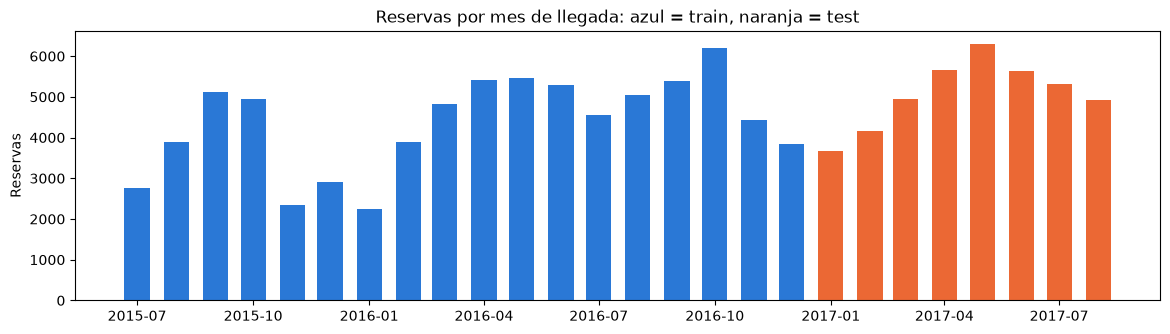

In [28]:
fig, ax = plt.subplots(figsize=(14, 3.5))
mensual = df.groupby(df['arrival_date'].dt.to_period('M')).size()
mensual.index = mensual.index.to_timestamp()
colores = [C_NO if f < pd.Timestamp(FECHA_CORTE) else C_SI for f in mensual.index]
ax.bar(mensual.index, mensual.values, width=20, color=colores)
ax.set_title('Reservas por mes de llegada: azul = train, naranja = test')
ax.set_ylabel('Reservas')
plt.show()

El gráfico confirma que el periodo de test (naranja) cubre tanto meses de temporada baja
(enero, febrero) como de temporada alta (mayo a agosto). La evaluación final no dependerá,
por tanto, de una época concreta del año.

---
## 5. Preprocesado y validación

Defino qué variables son **candidatas** a entrar en el modelo. Quedan fuera las de fuga, los IDs y
las que ya transformé.

- **Categóricas →** `OneHotEncoder`, con `handle_unknown='ignore'` por si en test apareciera una
  categoría que no está en train.
- **Numéricas →** `StandardScaler`. Es imprescindible para la Regresión Logística y no afecta a los
  árboles.

Meto todo en un `Pipeline` con un `ColumnTransformer`, que aplica cada transformación a su grupo de
columnas. Así el escalado y la codificación **se ajustan solo con los datos de entrenamiento** de cada
partición, y no hay fuga de información.

In [29]:
VARS_CAT = ['hotel', 'meal', 'country_grp', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']

# Las de fecha las trato aparte
VARS_FECHAS = ['arrival_month_num', 'arrival_date_week_number', 'arrival_date_day_of_month', 'arrival_weekday']
VARS_NUM = ['lead_time', 'lead_time_log', 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights', 'adults',
            'children', 'babies', 'total_guests', 'has_kids', 'is_repeated_guest', 'previous_cancellations',
            'previous_bookings_not_canceled', 'has_prev_cancel', 'has_prev_stays', 'adr', 'adr_per_person', 'ingreso_reserva',
            'total_of_special_requests', 'has_special_requests', 'is_domestic', 'has_agent', 'has_company']

CANDIDATAS = VARS_CAT + VARS_FECHAS + VARS_NUM

# Comprobación de seguridad: ninguna variable de fuga se ha colado
assert not set(CANDIDATAS) & set(VARIABLES_FUGA), 'Hay variables de fuga entre las candidatas'

X_train, y_train = train[CANDIDATAS], train['is_canceled']
X_test, y_test = test[CANDIDATAS], test['is_canceled']

print(f'Candidatas: {len(CANDIDATAS)} ({len(VARS_CAT)} categóricas + {len(VARS_FECHAS)} de fecha + {len(VARS_NUM)} numéricas)')
print(f'X_train: {X_train.shape} · X_test: {X_test.shape}')

Candidatas: 35 (8 categóricas + 4 de fecha + 23 numéricas)
X_train: (78584, 35) · X_test: (40619, 35)


Me quedan **35 variables candidatas**: 8 categóricas, 4 de fecha y 23 numéricas, sobre 78.584
reservas de entrenamiento y 40.619 de test.

Para no repetir el mismo montaje en cada modelo, defino dos funciones auxiliares:

- **`crear_preprocesador()`** construye el `ColumnTransformer` con el `OneHotEncoder` y el
  `StandardScaler` aplicados a sus columnas.
- **`crear_pipeline(modelo)`** encadena ese preprocesado con el modelo que le pase.

Así, cada vez que pruebe un algoritmo nuevo, el preprocesado será exactamente el mismo y la
comparación entre modelos será justa.

In [30]:
def crear_preprocesador(vars_cat=None, vars_num=None):
    """
    OneHotEncoder para las categoricas y StandardScaler para las numericas.
    Por defecto usa las listas VARS_CAT y VARS_NUM vigentes al llamar a la función.
    """
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), vars_cat or VARS_CAT),
        ('num', StandardScaler(), vars_num or VARS_NUM)
    ])  # Las columnas que no nombre se descartan

def crear_pipeline(modelo, vars_cat=None, vars_num=None):
    """
    Pipeline completo: preprocesado + modelo.
    """
    return Pipeline([('prep', crear_preprocesador(vars_cat, vars_num)), ('modelo', modelo)])

### Validación cruzada temporal

Para comparar modelos y buscar hiperparámetros **dentro del train** uso `TimeSeriesSplit`, que
siempre entrena con el pasado y valida con el periodo siguiente.

Lo configuro con **3 cortes** y bloques de validación de **10.000 reservas** (unos 2 meses cada uno),
de forma que **cada fold entrena con al menos 12 meses de historia**. Si un fold entrenara solo con
el verano de 2015, el modelo nunca habría visto un invierno y la validación penalizaría injustamente
a los modelos capaces de aprender patrones estacionales. El hotel siempre entrenará con un año
completo como mínimo, así que esto reproduce las condiciones reales de uso.

**Un ajuste sobre el comportamiento por defecto:** `TimeSeriesSplit` corta por posición de fila, y
como en un mismo día de llegada hay decenas de reservas, el corte podría caer en medio de un día. Para evitarlo, desplazo
cada corte al **principio del día**, de modo que todas las reservas de una misma fecha caen del mismo
lado.

In [31]:
tscv = TimeSeriesSplit(n_splits=3, test_size=10_000)

# Ajusto cada corte al día completo: todas las reservas de una misma fecha van al mismo lado
folds = []
for pos_train, pos_val in tscv.split(X_train):
    inicio_val = train['arrival_date'].iloc[pos_val[0]]     # Primer día del bloque de validación
    fin_val = train['arrival_date'].iloc[pos_val[-1]]       # Último día del bloque
    tr = np.where(train['arrival_date'] < inicio_val)[0]
    va = np.where((train['arrival_date'] >= inicio_val) & (train['arrival_date'] <= fin_val))[0]
    folds.append((tr, va))

for i, (tr, va) in enumerate(folds, 1):
    print(f'Fold {i}: entreno hasta {train['arrival_date'].iloc[tr[-1]].date()} ({len(tr):,} reservas) | '
          f'valido {train['arrival_date'].iloc[va[0]].date()} → '
          f'{train['arrival_date'].iloc[va[-1]].date()} ({len(va):,} reservas)')

Fold 1: entreno hasta 2016-06-26 (48,509 reservas) | valido 2016-06-27 → 2016-08-30 (10,081 reservas)
Fold 2: entreno hasta 2016-08-29 (58,458 reservas) | valido 2016-08-30 → 2016-10-23 (10,273 reservas)
Fold 3: entreno hasta 2016-10-22 (68,539 reservas) | valido 2016-10-23 → 2016-12-31 (10,045 reservas)


### Selección de variables: ¿aporta la fecha de llegada?

En el EDA vi que la cancelación tiene estacionalidad, así que lo lógico sería meter el mes en el
modelo. Pero hay un riesgo: variables como la **semana del año** o el **día del mes** pueden llevar al
modelo a **memorizar el calendario de un año concreto** ("la semana 42 de 2015 un grupo canceló 200
habitaciones"), y eso no se repite al año siguiente.

Antes de decidir, lo mido: entreno el mismo modelo (XGBoost con parámetros por defecto) **con y sin**
las variables de fecha, y comparo el AUC en la validación temporal.

In [32]:
xgb_ref = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=RANDOM_STATE)

exp_fechas = {}
for nombre, vn in {'Con variables de fecha': VARS_NUM + VARS_FECHAS, 'Sin variables de fecha': VARS_NUM}.items():
    s = cross_val_score(crear_pipeline(xgb_ref, VARS_CAT, vn), X_train, y_train, cv=folds, scoring='roc_auc')
    exp_fechas[nombre] = list(s) + [s.mean()]

pd.DataFrame(exp_fechas, index=['Fold 1', 'Fold 2', 'Fold 3', 'Media']).T.round(4)

,Fold 1,Fold 2,Fold 3,Media
Con variables de fecha,0.8059,0.8854,0.8575,0.8496
Sin variables de fecha,0.8484,0.9087,0.8648,0.8739


**Quitar las variables de fecha mejora el AUC en los tres folds** (media de 0,8496 a 0,8739).

Esto confirma la sospecha: el modelo estaba usando el calendario para memorizar episodios puntuales de
2015-2016 (grandes cancelaciones de grupos en fechas concretas) que no se repiten en 2017. La
información estacional útil le llega igualmente por otras vías: el **precio** (sube en temporada alta),
el **lead time** y el **segmento**.

**Decisión: el modelo final no usa las variables de fecha de llegada.** La estacionalidad la sigo
teniendo en cuenta en la política de negocio (intensificar acciones en temporada alta), que es la
conclusión a la que llegué en el EDA.

In [33]:
# Me quedo solo con las variables finales
X_train, X_test = X_train[VARS_CAT + VARS_NUM], X_test[VARS_CAT + VARS_NUM]
FEATURES = VARS_CAT + VARS_NUM
print(f'Variables finales del modelo: {len(FEATURES)}')

Variables finales del modelo: 31


---
## 6. Modelo Baseline — Regresión Logística

Empiezo con una Regresión Logística como referencia. Cualquier modelo más complejo tendrá que
superarla con claridad para compensar la pérdida de interpretabilidad.

Comparo los modelos por **AUC-ROC**, porque no depende del umbral de decisión y mide lo que de
verdad le interesa a Revenue Management: **ordenar** las reservas de más a menos riesgo para
priorizar sobre cuáles actuar. Calculo también el **PR-AUC**, más exigente con la clase minoritaria,
y el F1, la precisión y el recall como referencia, aunque estos tres dependen del umbral, que fijaré
más adelante.

In [34]:
# Métricas que calcularé para todos los modelos
METRICAS = {'auc': 'roc_auc', 'pr_auc': 'average_precision', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}

def evaluar_cv(pipe, nombre):
    """
    Validación cruzada temporal de un pipeline. Devuelve la media de cada métrica.
    """
    r = cross_validate(pipe, X_train, y_train, cv=folds, scoring=METRICAS, n_jobs=-1)
    resultado = {m: r[f'test_{m}'].mean() for m in METRICAS}
    resultado['auc_std'] = r['test_auc'].std()      # Variabilidad entre folds
    resultado['tiempo_s'] = r['fit_time'].mean()
    return pd.Series(resultado, name=nombre)

baseline = crear_pipeline(LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
res_baseline = evaluar_cv(baseline, 'Regresión Logística (baseline)')
res_baseline.to_frame().T.round(4)

,auc,pr_auc,f1,precision,recall,auc_std,tiempo_s
Regresión Logística (baseline),0.8616,0.8066,0.6103,0.8192,0.4868,0.0320,1.6856


El baseline parte de un **AUC de 0,8616**, con una desviación entre folds de 0,032: es estable, no
depende de que le toque un periodo concreto.

Lo interesante está en el resto de métricas, calculadas con el umbral por defecto de 0,5:

| Métrica | Valor | Lectura |
|---|---|---|
| Precisión | 0,8192 | De las reservas que marca como riesgo, 8 de cada 10 cancelan de verdad. |
| Recall | 0,4868 | Pero **solo detecta la mitad de las cancelaciones**: la otra mitad se le escapa. |
| F1 | 0,6103 | Consecuencia del recall bajo. |

Ese recall del 49% no es aceptable para el negocio: cada cancelación no detectada es una habitación
vacía. El problema no es el modelo en sí, sino que con las clases desbalanceadas (37% de positivos)
y un umbral de 0,5 el modelo se vuelve conservador y solo marca los casos más evidentes.

Lo abordaré por dos vías, más adelante: **corrigiendo el desbalanceo** en el entrenamiento y
**ajustando el umbral de decisión**, que es una decisión de negocio y no técnica.

### Qué dice el baseline

Como las variables numéricas están estandarizadas, cada coeficiente indica cuánto cambia el
*log-odds* de cancelar al aumentar esa variable en una desviación típica. Coeficiente positivo,
más riesgo; negativo, menos.

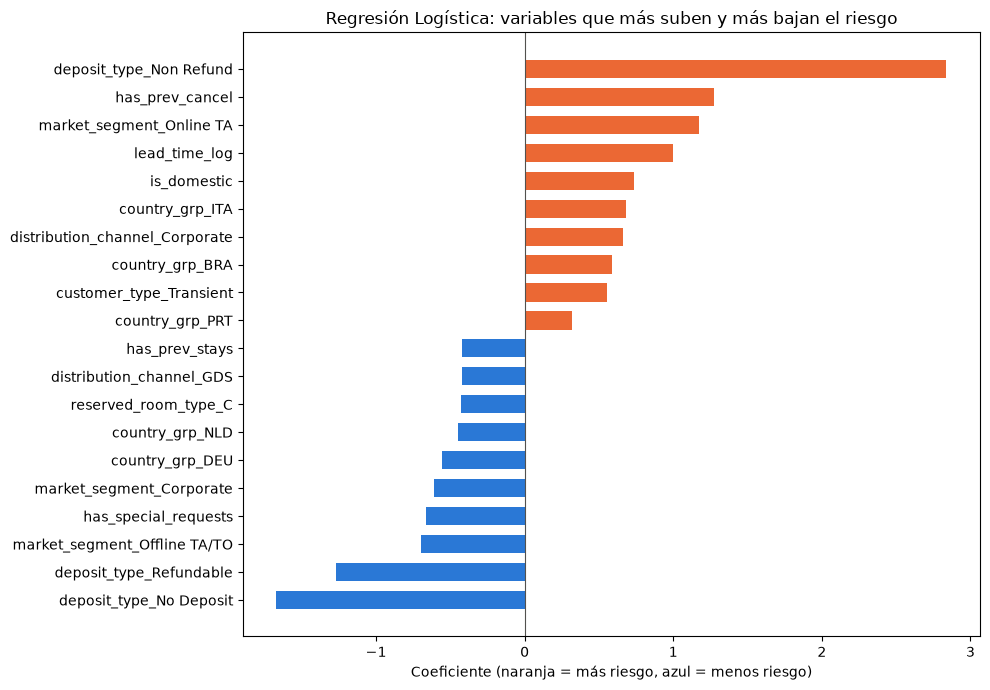

In [35]:
baseline.fit(X_train, y_train)

# Recupero los nombres de las columnas que genera el preprocesado
nombres = baseline.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(baseline.named_steps['modelo'].coef_[0], index=nombres)
coefs.index = coefs.index.str.replace('cat__', '').str.replace('num__', '')

# Las 10 que más suben el riesgo y las 10 que más lo bajan
top_coefs = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_coefs.index, top_coefs.values, color=[C_SI if v > 0 else C_NO for v in top_coefs.values], height=0.65)
ax.axvline(0, color='#52514e', lw=0.8)
ax.set_title('Regresión Logística: variables que más suben y más bajan el riesgo')
ax.set_xlabel('Coeficiente (naranja = más riesgo, azul = menos riesgo)')
plt.tight_layout()
plt.show()

Los coeficientes confirman lo que vi en el EDA, lo cual es buena señal: el modelo no está
aprendiendo nada raro.

**Suben el riesgo:** el **depósito no reembolsable** (con diferencia el coeficiente más alto, +2,85),
haber **cancelado antes** (+1,28), reservar por **agencia online** (+1,17), la **antelación**
(+1,00 en escala logarítmica) y ser **cliente nacional** (+0,73).

**Lo bajan:** reservar **sin depósito** (−1,70) o con depósito reembolsable (−1,28), venir de
**turoperador** (−0,69), haber hecho **peticiones especiales** (−0,65), el segmento **corporativo**
(−0,60) y tener **estancias previas sin cancelar** (−0,42).

---
## 7. Modelos 




Pruebo los algoritmos supervisados con el **mismo preprocesado y la misma validación temporal**, para
que la comparación sea justa. Todos con hiperparámetros por defecto o valores razonables: la
optimización viene después, y solo para los mejores.

- **Árbol de decisión:** interpretable, pero un árbol solo tiende al sobreajuste. Le limito la
  profundidad a 10.
- **Naive Bayes:** muy rápido, aunque supone independencia entre variables, algo que aquí no se
  cumple (`lead_time` y `lead_time_log`, por ejemplo, son la misma información).
- **Random Forest, XGBoost y LightGBM:** conjuntos de árboles, capaces de captar relaciones no
  lineales e interacciones entre variables.

**Dejo fuera SVM y KNN.** Con casi 80.000 reservas de entrenamiento, entrenar un SVM tiene un coste
que crece de forma más que lineal con el número de filas, y KNN necesita comparar cada reserva nueva
con todo el histórico para predecir. Ninguno es práctico para un sistema que debe puntuar reservas
en tiempo real en el motor de reservas del hotel.

In [36]:
modelos = {
    'Árbol de decisión': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
}

resultados = [res_baseline]
for nombre, modelo in modelos.items():
    resultados.append(evaluar_cv(crear_pipeline(modelo), nombre))

comparativa = pd.DataFrame(resultados).sort_values('auc', ascending=False)
comparativa.round(4)

,auc,pr_auc,f1,precision,recall,auc_std,tiempo_s
XGBoost,0.8739,0.8260,0.6645,0.8376,0.5514,0.0254,7.0683
LightGBM,0.8682,0.8203,0.6601,0.8448,0.5428,0.0262,4.5113
Random Forest,0.8674,0.8225,0.6574,0.8526,0.5359,0.0264,18.2106
Regresión Logística (baseline),0.8616,0.8066,0.6103,0.8192,0.4868,0.0320,1.6856
Árbol de decisión,0.8524,0.7888,0.6798,0.8136,0.5853,0.0338,0.9673
Naive Bayes,0.7540,0.7093,0.5582,0.6928,0.4692,0.0377,0.2445


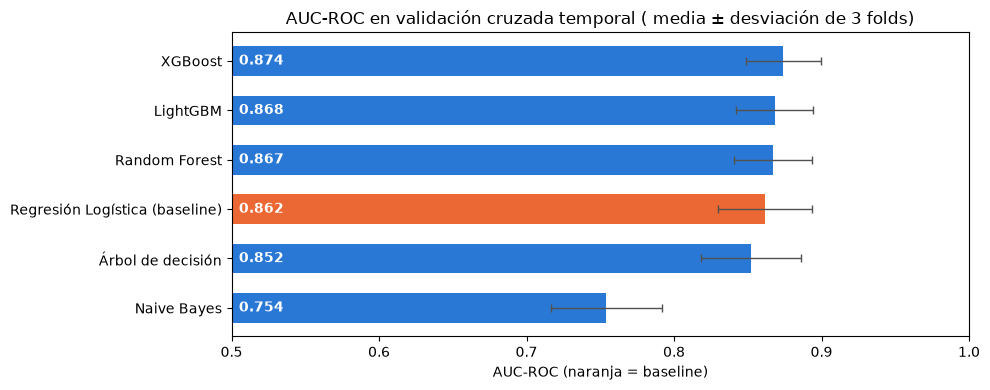

In [37]:
orden = comparativa.sort_values('auc')
colores = [C_SI if 'baseline' in n else C_NO for n in orden.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(orden.index, orden['auc'], xerr=orden['auc_std'], color=colores, height=0.6, error_kw={'ecolor': '#52514e', 'lw': 1, 'capsize': 3})
for i, v in enumerate(orden['auc']):
    ax.text(0.505, i, f'{v:.3f}', va='center', color='white', fontweight='bold')
ax.set_xlim(0.5, 1)
ax.set_title('AUC-ROC en validación cruzada temporal ( media ± desviación de 3 folds)')
ax.set_xlabel('AUC-ROC (naranja = baseline)')
plt.tight_layout()
plt.show()

**XGBoost es el mejor modelo** (AUC 0,874), seguido de LightGBM (0,868) y Random Forest (0,867).
Los tres superan al baseline (0,862), aunque la ventaja es moderada: entre 0,5 y 1,2 puntos. Los
*ensembles* captan interacciones que un modelo lineal no puede ver, como que una antelación larga es
mucho más peligrosa si además la reserva viene de una agencia online.

El **árbol de decisión** individual se queda por debajo del baseline (0,852): un solo árbol
generaliza peor que un conjunto de ellos. **Naive Bayes** es el peor con diferencia (0,754), como
era previsible, porque su supuesto de independencia entre variables aquí no se cumple.

**Me quedo con XGBoost** para las siguientes fases. También optimizaré Random Forest y la Regresión
Logística, para comprobar que la ventaja se mantiene una vez ajustados los hiperparámetros.

Con un 37% de cancelaciones, las clases están desbalanceadas y el modelo se inclina hacia la clase
mayoritaria: solo marca como riesgo los casos más evidentes. De ahí el recall bajo que acabo de ver.

Comparo las dos técnicas que conozco, aplicadas sobre XGBoost:

1. **Sin corrección**, como referencia.
2. **Pesos por clase.** En XGBoost se hace con `scale_pos_weight`, que es el equivalente al
   `class_weight='balanced'` de scikit-learn: los errores sobre la clase minoritaria penalizan más.
3. **SMOTE.** Genera reservas sintéticas de la clase minoritaria. Va dentro de un `ImbPipeline`
   para que se aplique **solo al train de cada fold** y nunca a los datos de validación; si se
   aplicara antes de partir, habría fuga de información.

In [38]:
# scale_pos_weight = nº de negativos / nº de positivos
PESO_POSITIVOS = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {PESO_POSITIVOS:.2f}')

def xgb_base(**kw):
    return XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=RANDOM_STATE, **kw)

opciones_desbalanceo = {
    'Sin corrección': crear_pipeline(xgb_base()),
    'Pesos por clase': crear_pipeline(xgb_base(scale_pos_weight=PESO_POSITIVOS)),
    'SMOTE': ImbPipeline([
        ('prep', crear_preprocesador()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('modelo', xgb_base())
    ]),
}

res_desb = pd.DataFrame([evaluar_cv(p, n) for n, p in opciones_desbalanceo.items()])
res_desb[['auc', 'pr_auc', 'f1', 'precision', 'recall', 'tiempo_s']].round(4)

scale_pos_weight = 1.76


,auc,pr_auc,f1,precision,recall,tiempo_s
Sin corrección,0.8739,0.8260,0.6645,0.8376,0.5514,7.0229
Pesos por clase,0.8724,0.8241,0.6999,0.7926,0.6279,5.5699
SMOTE,0.8782,0.8306,0.6931,0.8178,0.6025,13.6488


| Opción | AUC | PR-AUC | F1 | Precisión | Recall | Tiempo |
|---|---|---|---|---|---|---|
| Sin corrección | 0,8739 | 0,8260 | 0,6645 | 0,8376 | 0,5514 | 6,29 s |
| Pesos por clase | 0,8724 | 0,8241 | **0,6999** | 0,7926 | **0,6279** | 5,52 s |
| SMOTE | **0,8782** | **0,8306** | 0,6931 | 0,8178 | 0,6025 | 13,19 s |

Lo primero que salta a la vista es que **el AUC apenas se mueve** (0,8724 a 0,8782). Tiene sentido:
corregir el desbalanceo no cambia la capacidad del modelo para **ordenar** las reservas por riesgo,
sino **dónde** coloca la frontera entre las dos clases. Además, esa diferencia de 0,0058 es muy
inferior a la variabilidad entre folds (±0,0254), así que no la considero concluyente.

Donde sí hay diferencia clara es en el **recall**: sube de 0,5514 a 0,6279 con pesos por clase y a
0,6025 con SMOTE. El F1 mejora en los dos casos, y el mejor es el de pesos por clase (0,6999).

**Decisión: uso pesos por clase (`scale_pos_weight = 1,76`).** Tiene el mejor F1 y el mejor recall,
**no genera reservas sintéticas** y tarda menos de la mitad que SMOTE.

## 8. Optimizacion



Aplico los tres métodos de búsqueda, asignando a cada modelo el que mejor encaja con su espacio de
hiperparámetros:

| Modelo | Método | Por qué |
|---|---|---|
| Regresión Logística | `GridSearchCV` | Pocos hiperparámetros (C y tipo de penalización), así que puedo probar todas las combinaciones. |
| Random Forest | `RandomizedSearchCV` | Espacio bastante mayor. Muestrear combinaciones al azar cuesta mucho menos que probarlas todas y da resultados similares. |
| XGBoost | `Optuna` | Muchos hiperparámetros continuos. Optuna aprende de los intentos anteriores y concentra la búsqueda donde hay margen de mejora. |

En los tres casos uso la **misma validación temporal** (`folds`) y optimizo el **AUC-ROC**, para que
los resultados sean comparables entre sí y con la tabla anterior.

### 8.1 Regresión Logística con GridSearchCV

Busco sobre dos hiperparámetros: `C`, que es el inverso de la regularización (valores bajos
regularizan más), y `penalty`, que elige entre Lasso (`l1`, capaz de anular variables) y Ridge
(`l2`, que solo las encoge). Son 8 combinaciones, así que las pruebo todas.

Uso `solver='liblinear'` porque es el que admite las dos penalizaciones, y `class_weight='balanced'`
en coherencia con la decisión sobre el desbalanceo.

In [39]:
grid_lr = GridSearchCV(
    crear_pipeline(LogisticRegression(max_iter=3000, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)),
    param_grid={
        'modelo__C': [0.01, 0.1, 1, 10],
        'modelo__penalty': ['l1', 'l2']
    },
    cv=folds, n_jobs=-1, scoring='roc_auc'
)

grid_lr.fit(X_train, y_train)
print('Mejores parámetros:', grid_lr.best_params_)
print(f'AUC CV: {grid_lr.best_score_:.4f} (baseline sin optimizar: {res_baseline['auc']:.4f})')

Mejores parámetros: {'modelo__C': 0.01, 'modelo__penalty': 'l2'}
AUC CV: 0.8618 (baseline sin optimizar: 0.8616)


### 8.2 Random Forest con RandomizedSearchCV

Aquí el espacio es mucho mayor: número de árboles, profundidad máxima, tamaño mínimo de hoja y
número de variables por división suman 144 combinaciones posibles. Probarlas todas con validación
cruzada serían 432 bosques, así que muestreo **8 combinaciones al azar**.

Pongo `n_jobs=1` en la búsqueda porque el propio Random Forest ya usa todos los núcleos con su
`n_jobs=-1`.

In [40]:
rand_rf = RandomizedSearchCV(
    crear_pipeline(RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=RANDOM_STATE)),
    param_distributions={
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [10, 15, 20, None],
        'modelo__min_samples_leaf': [1, 2, 5, 10],
        'modelo__max_features': ['sqrt', 0.3, 0.5]
    },
    n_iter=8, cv=folds, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=1
)

rand_rf.fit(X_train, y_train)
print('Mejores parámetros:', rand_rf.best_params_)
print(f'AUC CV: {rand_rf.best_score_:.4f} (sin optimizar: {comparativa.loc['Random Forest', 'auc']:.4f})')

Mejores parámetros: {'modelo__n_estimators': 100, 'modelo__min_samples_leaf': 1, 'modelo__max_features': 0.3, 'modelo__max_depth': 10}
AUC CV: 0.8762 (sin optimizar: 0.8674)


### 8.3 XGBoost con Optuna

XGBoost tiene muchos hiperparámetros y varios son continuos, así que una rejilla fija es poco
eficiente: o es demasiado gruesa, o se dispara el número de combinaciones.

Optuna funciona distinto: en cada intento propone una combinación, la evalúa con la validación
temporal y **usa lo aprendido para decidir la siguiente**. Los primeros intentos son casi
aleatorios, pero a partir de ahí concentra la búsqueda en las zonas donde el AUC sale más alto.

Lanzo 25 intentos, unos 3 minutos. La semilla del `TPESampler` hace que la búsqueda sea
reproducible: al volver a ejecutar, probará exactamente los mismos 25 intentos.

In [42]:
def objetivo_xgb(trial):
    """
    Optuna llama a esta función en cada intento. Devuelve el AUC medio en la validación temporal
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 20, log=True),
    }
    pipe = crear_pipeline(XGBClassifier(**params, scale_pos_weight=PESO_POSITIVOS, n_jobs=-1, random_state=RANDOM_STATE))
    return cross_val_score(pipe, X_train, y_train, cv=folds, scoring='roc_auc').mean()

estudio = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio.optimize(objetivo_xgb, n_trials=25)

print('Mejores parámetros:')
for k, v in estudio.best_params.items():
    print(f' {k}: {v}')
print(f'\nAUC CV: {estudio.best_value:.4f} (sin optimizar: {comparativa.loc['XGBoost', 'auc']:.4f})')

Mejores parámetros:
 n_estimators: 300
 learning_rate: 0.02810415932563298
 max_depth: 5
 min_child_weight: 11
 subsample: 0.813845078886668
 colsample_bytree: 0.9373321387720607
 gamma: 4.424924698988237
 reg_lambda: 0.019039747776829964

AUC CV: 0.8831 (sin optimizar: 0.8739)


El gráfico siguiente muestra cómo ha ido la búsqueda: cada punto es un intento y la línea marca el
mejor resultado acumulado.

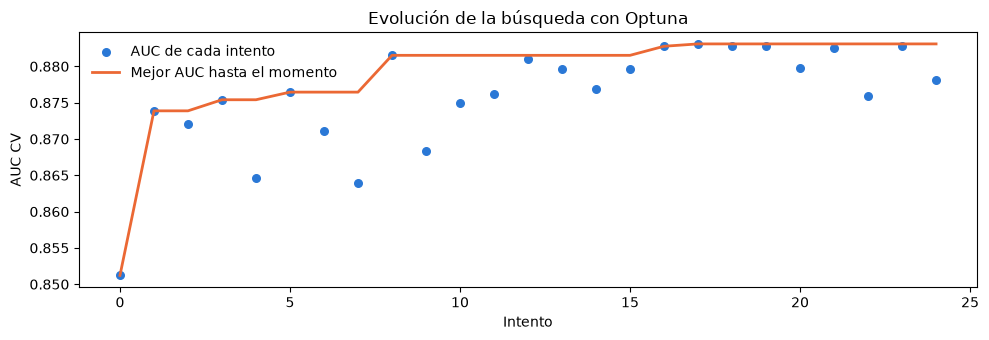

In [43]:
historial = estudio.trials_dataframe()[['number', 'value']]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(historial['number'], historial['value'], color=C_NO, s=30, label='AUC de cada intento')
ax.plot(historial['number'], historial['value'].cummax(), color=C_SI, lw=2, label='Mejor AUC hasta el momento')
ax.set_xlabel('Intento')
ax.set_ylabel('AUC CV')
ax.set_title('Evolución de la búsqueda con Optuna')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 8.4 Comparativa de los tres modelos optimizados

Pongo juntos el AUC antes y después de optimizar, para ver cuánto ha aportado realmente la búsqueda
en cada caso.

In [44]:
optimizados = pd.DataFrame({
    'AUC sin optimizar': [res_baseline['auc'], comparativa.loc['Random Forest', 'auc'], comparativa.loc['XGBoost', 'auc']],
    'AUC optimizado': [grid_lr.best_score_, rand_rf.best_score_, estudio.best_value],
    'Método': ['GridSearchCV', 'RandomizedSearchCV', 'Optuna'],
}, index=['Regresión Logística', 'Random Forest', 'XGBoost'])
optimizados['Mejora'] = optimizados['AUC optimizado'] - optimizados['AUC sin optimizar']
optimizados.round(4)

,AUC sin optimizar,AUC optimizado,Método,Mejora
Regresión Logística,0.8616,0.8618,GridSearchCV,0.0003
Random Forest,0.8674,0.8762,RandomizedSearchCV,0.0089
XGBoost,0.8739,0.8831,Optuna,0.0092


---
## 9. Comparación de modelos Seleccion del modelo ganador



| Modelo | AUC sin optimizar | AUC optimizado | Método | Mejora |
|---|---|---|---|---|
| Regresión Logística | 0,8616 | 0,8618 | GridSearchCV | +0,0003 |
| Random Forest | 0,8674 | 0,8762 | RandomizedSearchCV | +0,0089 |
| **XGBoost** | 0,8739 | **0,8831** | Optuna | **+0,0092** |

**XGBoost optimizado con Optuna es el modelo ganador**, con un AUC de 0,8831 en validación temporal.

Tres lecturas de esta tabla:

- **La Regresión Logística no mejora nada** (+0,0002). Es lo esperable: un modelo lineal tiene muy
  poco margen de ajuste, y su techo lo marca la propia forma del modelo, no sus hiperparámetros. La
  mejor configuración resulta ser `C=0.01`, es decir, **mucha regularización**, lo que indica que
  con 60 columnas *dummy* el modelo prefiere coeficientes pequeños para no sobreajustar.
- **Random Forest gana casi un punto** y se queda a 0,007 de XGBoost. Curiosamente, la mejor
  configuración es la más contenida de las probadas: 100 árboles y profundidad máxima 10.
- **XGBoost es el que más gana y el que más alto llega.** Optuna ha elegido árboles poco profundos
  (`max_depth=5`) y muy regularizados (`gamma=4,42`, `min_child_weight=11`, `learning_rate=0,028`).

Ese patrón se repite en los tres modelos: **las configuraciones más simples y regularizadas ganan a
las complejas**. Tiene sentido de negocio. Con datos que cambian de un año a otro, un modelo que
memoriza los detalles del pasado generaliza peor al futuro que uno que aprende las tendencias
generales. Es la misma conclusión a la que llegué al descartar las variables de fecha.

**Modelo final: XGBoost con los hiperparámetros de Optuna y `scale_pos_weight` para el desbalanceo.**

---
## 11. Interpretabilidad


Analizamos los resultados analizando como se comportan las variables.   
Identificamos las variables que mas importancia tienen y en que sentido influyen al la variable objetivo


